# Naive-to-MRCA Mutation Analysis

This notebook shows the distribution of naive-to-MRCA **nucleotide** mutations across Rodriguez, Jaffe, and Tang datasets:
- **Full sequence**: nt mutations between naive and MRCA (from with-naive PCP files, non-NI/non-MASKED)
- **IGHV region** (Chothia 1-94): nt differences between MRCA codon and germline codon via `load_and_process_dnsm_data` (depth-2 PCPs, parent=MRCA)

Both methods count nucleotide changes (multiple nt changes in one codon are counted individually). Families are filtered to those present in the no-naive (training) dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from netam.sequences import translate_sequence
from utils import load_and_process_dnsm_data

## Dataset definitions

In [2]:
DATASETS = {
    "Rodriguez": {
        "with_naive": "/home/nharel/data/v3/rodriguez-airr-seq-race-prod-NoWinCheck_igh_pcp_2024-11-12.csv.gz",
        "no_naive": "/home/nharel/data/v3/rodriguez-airr-seq-race-prod-NoWinCheck_igh_pcp_2024-11-12_MASKED_NI_noN_no-naive.csv.gz",
        "dnsm_dataset": "v1rodriguez",
    },
    "Jaffe": {
        "with_naive": "/home/nharel/data/v3/wyatt-10x-1p5m_fs-all-NoWinCheck_igh_pcp_2024-10-29.csv.gz",
        "no_naive": "/home/nharel/data/v3/wyatt-10x-1p5m_fs-all-NoWinCheck_igh_pcp_2024-10-29_NI_noN_no-naive.csv.gz",
        "dnsm_dataset": "v1jaffe",
    },
    "Tang": {
        "with_naive": "/home/nharel/data/v3/tang-deepshm-prod-NoWinCheck_igh_pcp_2024-10-29.csv.gz",
        "no_naive": "/home/nharel/data/v3/tang-deepshm-prod-NoWinCheck_igh_pcp_2024-10-29_MASKED_NI_noN_no-naive.csv.gz",
        "dnsm_dataset": "v1tang",
    },
}

DNSM_MODEL = "dnsm_1m-v1jaffe+v1tang-joint"

In [3]:
def get_naive_pcps_filtered(with_naive_path, no_naive_path):
    """Load with-naive PCPs, filter to naive-to-MRCA edges for families in no-naive dataset."""
    with_naive = pd.read_csv(with_naive_path)
    no_naive = pd.read_csv(no_naive_path)

    naive_pcps = with_naive[with_naive["parent_is_naive"] == True].copy()

    nn_families = set(zip(no_naive["sample_id"], no_naive["family"].astype(str)))
    naive_pcps["family_str"] = naive_pcps["family"].astype(str)
    mask = [
        (sid, fam) in nn_families
        for sid, fam in zip(naive_pcps["sample_id"], naive_pcps["family_str"])
    ]
    naive_pcps = naive_pcps[mask].copy()

    # Normalize column names
    if "v_gene_heavy" in naive_pcps.columns:
        naive_pcps["v_gene"] = naive_pcps["v_gene_heavy"]
    if "parent_heavy" in naive_pcps.columns:
        naive_pcps["parent"] = naive_pcps["parent_heavy"]
        naive_pcps["child"] = naive_pcps["child_heavy"]

    return naive_pcps


def count_nt_mutations(seq_a, seq_b):
    """Count nucleotide differences between two sequences."""
    return sum(a != b for a, b in zip(seq_a, seq_b))


def count_full_sequence_mutations(naive_pcps):
    """Count nt and AA mutations for the full sequence (naive vs MRCA)."""
    parent_nt = naive_pcps["parent"].values
    child_nt = naive_pcps["child"].values

    n_nt = np.array([count_nt_mutations(p, c) for p, c in zip(parent_nt, child_nt)])

    parent_aa = [translate_sequence(s) for s in parent_nt]
    child_aa = [translate_sequence(s) for s in child_nt]
    n_aa = np.array([sum(a != b for a, b in zip(p, c)) for p, c in zip(parent_aa, child_aa)])

    return pd.DataFrame({
        "sample_id": naive_pcps["sample_id"].values,
        "family": naive_pcps["family_str"].values,
        "v_gene": naive_pcps["v_gene"].values,
        "branch_length": naive_pcps["branch_length"].values,
        "n_nt_full": n_nt,
        "n_aa_full": n_aa,
    })

## 1. Full-sequence mutations (naive vs MRCA)

In [4]:
# Full-sequence mutation counts for all datasets
full_seq_dfs = {}
for name, paths in DATASETS.items():
    print(f"Processing {name}...")
    naive_pcps = get_naive_pcps_filtered(paths["with_naive"], paths["no_naive"])
    mdf = count_full_sequence_mutations(naive_pcps)
    mdf["dataset"] = name
    full_seq_dfs[name] = mdf
    print(f"  {len(mdf)} naive-to-MRCA PCPs, "
          f"median nt={mdf['n_nt_full'].median():.0f}, median AA={mdf['n_aa_full'].median():.0f}")

Processing Rodriguez...


  7603 naive-to-MRCA PCPs, median nt=15, median AA=10
Processing Jaffe...


  57200 naive-to-MRCA PCPs, median nt=7, median AA=5
Processing Tang...


  145032 naive-to-MRCA PCPs, median nt=8, median AA=5


## 2. IGHV-region mutations (MRCA vs germline, via DNSM site-level data)

Use `load_and_process_dnsm_data` to get per-site germline annotations. In depth-2 PCPs the parent is the MRCA, so `is_germline_codon == False` counts MRCA mutations relative to germline.

In [5]:
# IGHV-region mutation counts via DNSM site-level data
ighv_dfs = {}
for name, paths in DATASETS.items():
    print(f"Processing {name}...")
    site_df, pcp_df = load_and_process_dnsm_data(
        model_name=DNSM_MODEL,
        dataset_name=paths["dnsm_dataset"],
        numbering_scheme="chothia",
    )

    depth2_pcp = pcp_df[pcp_df["depth"] == 2].copy()
    depth2_pcp["family_str"] = depth2_pcp["family"].astype(str)
    depth2_sites = site_df[site_df["pcp_index"].isin(depth2_pcp.index)]

    # Count nucleotide differences between parent_codon and germline_codon per site
    valid = depth2_sites.dropna(subset=["germline_codon", "parent_codon"]).copy()
    valid["n_nt_at_site"] = [
        count_nt_mutations(p, g)
        for p, g in zip(valid["parent_codon"], valid["germline_codon"])
    ]
    nt_counts = valid.groupby("pcp_index")["n_nt_at_site"].sum()

    # Count non-germline AAs per PCP
    valid_aa = depth2_sites.dropna(subset=["is_germline_aa"])
    aa_counts = valid_aa.groupby("pcp_index")["is_germline_aa"].apply(lambda x: (x == False).sum())

    # Take one PCP per family (all depth-2 in same family share the same MRCA parent)
    common_idx = nt_counts.index.intersection(aa_counts.index)
    result_df = depth2_pcp.loc[common_idx, ["sample_id", "family_str", "v_gene"]].copy()
    result_df["n_nt_ighv"] = nt_counts.loc[common_idx].values
    result_df["n_aa_ighv"] = aa_counts.loc[common_idx].values
    result_df = result_df.drop_duplicates(subset=["sample_id", "family_str"], keep="first")
    result_df["dataset"] = name
    ighv_dfs[name] = result_df

    print(f"  {len(result_df)} families, "
          f"median nt={result_df['n_nt_ighv'].median():.0f}, "
          f"median AA={result_df['n_aa_ighv'].median():.0f}")

Processing Rodriguez...


  7681 families, median nt=13, median AA=8
Processing Jaffe...


  55662 families, median nt=7, median AA=4
Processing Tang...


  139325 families, median nt=6, median AA=4


In [6]:
# Intersect families: keep only those present in both methods
for name in DATASETS:
    full = full_seq_dfs[name]
    ighv = ighv_dfs[name]

    full_families = set(zip(full["sample_id"], full["family"]))
    ighv_families = set(zip(ighv["sample_id"], ighv["family_str"]))
    common = full_families & ighv_families

    n_full_before, n_ighv_before = len(full), len(ighv)
    full_seq_dfs[name] = full[
        [((s, f) in common) for s, f in zip(full["sample_id"], full["family"])]
    ].copy()
    ighv_dfs[name] = ighv[
        [((s, f) in common) for s, f in zip(ighv["sample_id"], ighv["family_str"])]
    ].copy()

    print(f"{name}: {n_full_before} full, {n_ighv_before} IGHV -> {len(common)} common families")

Rodriguez: 7603 full, 7681 IGHV -> 7527 common families
Jaffe: 57200 full, 55662 IGHV -> 55562 common families


Tang: 145032 full, 139325 IGHV -> 137692 common families


## 3. Combined plots

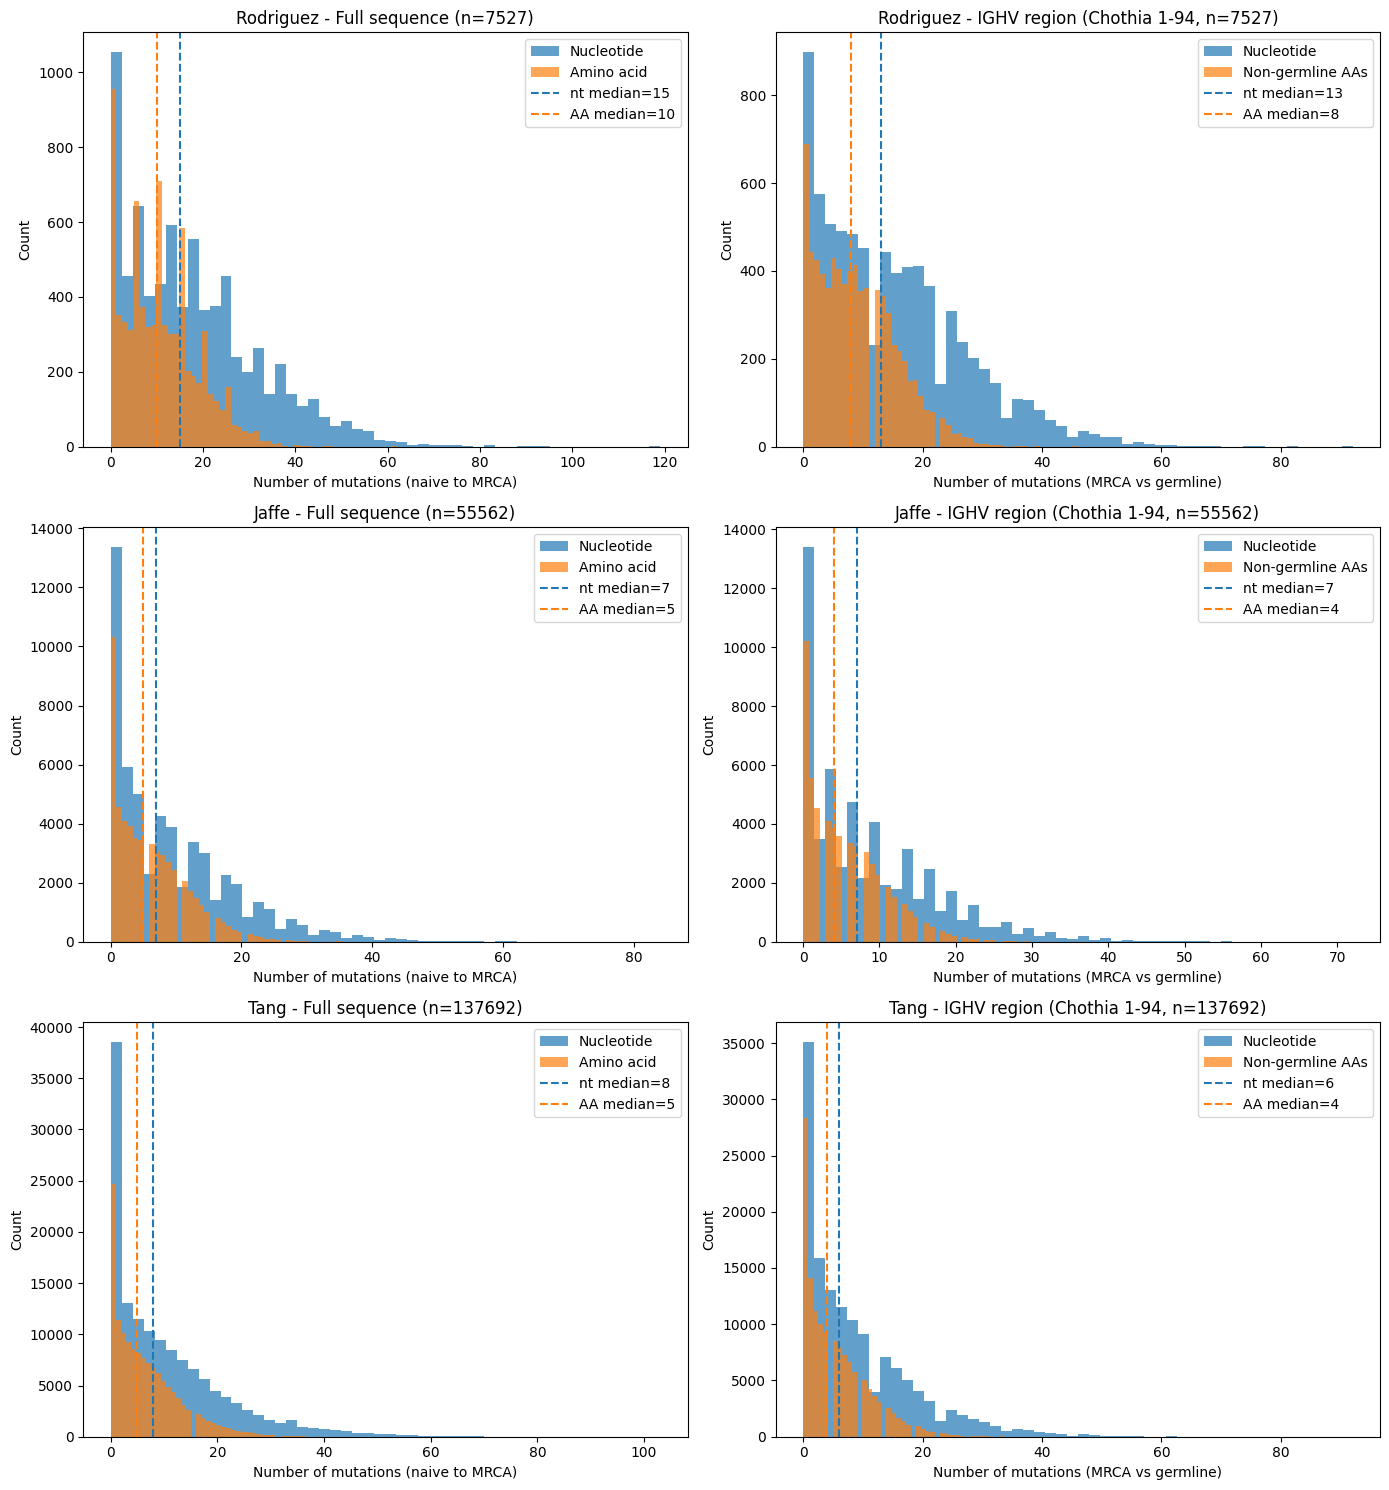

Dataset       n_full  n_ighv   nt full  AA full  nt IGHV  AA IGHV
Rodriguez       7527    7527        15       10       13        8
Jaffe          55562   55562         7        5        7        4
Tang          137692  137692         8        5        6        4


In [7]:
fig, axes = plt.subplots(len(DATASETS), 2, figsize=(14, 5 * len(DATASETS)))

for i, name in enumerate(DATASETS):
    full = full_seq_dfs[name]
    ighv = ighv_dfs[name]

    # Full sequence
    ax = axes[i, 0]
    ax.hist(full["n_nt_full"], bins=50, alpha=0.7, label="Nucleotide")
    ax.hist(full["n_aa_full"], bins=50, alpha=0.7, label="Amino acid")
    ax.axvline(full["n_nt_full"].median(), color="C0", linestyle="--",
               label=f"nt median={full['n_nt_full'].median():.0f}")
    ax.axvline(full["n_aa_full"].median(), color="C1", linestyle="--",
               label=f"AA median={full['n_aa_full'].median():.0f}")
    ax.set_xlabel("Number of mutations (naive to MRCA)")
    ax.set_ylabel("Count")
    ax.set_title(f"{name} - Full sequence (n={len(full)})")
    ax.legend()

    # IGHV region
    ax = axes[i, 1]
    ax.hist(ighv["n_nt_ighv"], bins=50, alpha=0.7, label="Nucleotide")
    ax.hist(ighv["n_aa_ighv"], bins=50, alpha=0.7, label="Non-germline AAs")
    ax.axvline(ighv["n_nt_ighv"].median(), color="C0", linestyle="--",
               label=f"nt median={ighv['n_nt_ighv'].median():.0f}")
    ax.axvline(ighv["n_aa_ighv"].median(), color="C1", linestyle="--",
               label=f"AA median={ighv['n_aa_ighv'].median():.0f}")
    ax.set_xlabel("Number of mutations (MRCA vs germline)")
    ax.set_ylabel("Count")
    ax.set_title(f"{name} - IGHV region (Chothia 1-94, n={len(ighv)})")
    ax.legend()

plt.tight_layout()
plt.show()

# Summary table
print(f"{'Dataset':<12} {'n_full':>7} {'n_ighv':>7}  {'nt full':>8} {'AA full':>8} {'nt IGHV':>8} {'AA IGHV':>8}")
for name in DATASETS:
    full = full_seq_dfs[name]
    ighv = ighv_dfs[name]
    print(f"{name:<12} {len(full):>7} {len(ighv):>7}  "
          f"{full['n_nt_full'].median():>8.0f} {full['n_aa_full'].median():>8.0f} "
          f"{ighv['n_nt_ighv'].median():>8.0f} {ighv['n_aa_ighv'].median():>8.0f}")

## 3b. Validation: do DNSM (MRCA vs germline) and PCP (naive vs MRCA) agree in the IGHV?

Two ways to count IGHV mutations:
- **Method A (DNSM)**: MRCA codon vs germline codon at Chothia sites 1-94 (~98 physical codons, including insertion sites 31A/B, 52A-C, 82A-C)
- **Method B (PCP)**: naive vs MRCA nucleotides, using the same number of codons as Method A per family (derived from the DNSM site count)

**Note on CDR3 boundary**: `cdr3_codon_start_heavy` in the PCP uses the AIRR CDR3 definition, which starts ~2 codons earlier than Chothia site 95. So we match Method B's coverage to Method A's by using the DNSM's per-family site count rather than `cdr3_codon_start_heavy`.

If partis naive ≈ OGRDB germline in the IGHV, the two methods should agree. Disagreements reveal sites where naive ≠ germline.

Families compared: 7527
  Agree exactly:  6047 (80.3%)
  Disagree:       1480 (19.7%)

Difference (A - B) value counts:
diff
-2.0        2
-1.0        7
 0.0     6047
 1.0      763
 2.0      389
 3.0      182
 4.0       81
 5.0       43
 6.0       10
 7.0        2
 14.0       1


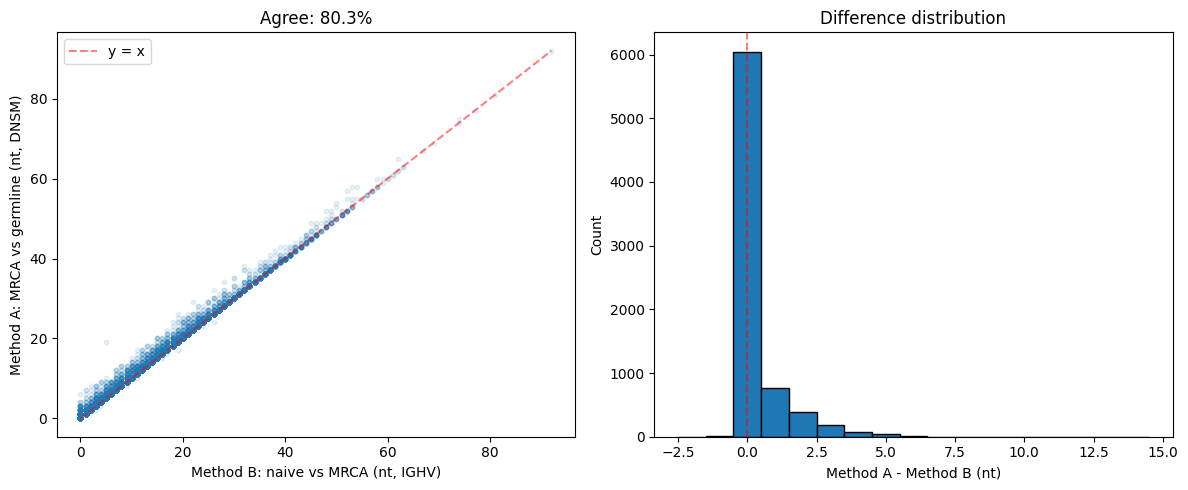

In [8]:
# --- Method A: DNSM per-site data (MRCA vs germline, Chothia 1-94) ---
rod_site_df, rod_pcp_df = load_and_process_dnsm_data(
    model_name=DNSM_MODEL, dataset_name="v1rodriguez", numbering_scheme="chothia",
)
rod_depth2 = rod_pcp_df[rod_pcp_df["depth"] == 2].copy()
rod_depth2["family_str"] = rod_depth2["family"].astype(str)
rod_depth2_dedup = rod_depth2.drop_duplicates(subset=["sample_id", "family_str"], keep="first")

# Per-PCP: count germline sites and nt mutations
d2_sites = rod_site_df[rod_site_df["pcp_index"].isin(rod_depth2_dedup.index)]
valid_a = d2_sites.dropna(subset=["germline_codon", "parent_codon"]).copy()
valid_a["n_nt"] = [count_nt_mutations(p, g) for p, g in zip(valid_a["parent_codon"], valid_a["germline_codon"])]
method_a_nt = valid_a.groupby("pcp_index")["n_nt"].sum()
method_a_nsites = valid_a.groupby("pcp_index").size()  # number of IGHV codons per PCP

# --- Method B: naive vs MRCA, matched to same codon count as Method A ---
rod_naive_pcps = get_naive_pcps_filtered(
    DATASETS["Rodriguez"]["with_naive"], DATASETS["Rodriguez"]["no_naive"]
)
naive_seq_lookup = dict(zip(
    zip(rod_naive_pcps["sample_id"], rod_naive_pcps["family_str"]),
    rod_naive_pcps["parent"]
))
mrca_seq_lookup = dict(zip(
    zip(rod_naive_pcps["sample_id"], rod_naive_pcps["family_str"]),
    rod_naive_pcps["child"]
))

method_b_data = []
for pcp_idx, row in rod_depth2_dedup.iterrows():
    key = (row["sample_id"], row["family_str"])
    if key not in naive_seq_lookup or pcp_idx not in method_a_nsites.index:
        continue
    n_codons = method_a_nsites.loc[pcp_idx]
    naive_ighv = naive_seq_lookup[key][:n_codons * 3]
    mrca_ighv = mrca_seq_lookup[key][:n_codons * 3]
    method_b_data.append({
        "pcp_index": pcp_idx,
        "sample_id": row["sample_id"], "family_str": row["family_str"],
        "n_nt_b": count_nt_mutations(naive_ighv, mrca_ighv),
        "n_codons": n_codons,
    })
method_b_df = pd.DataFrame(method_b_data).set_index("pcp_index")

# --- Merge ---
method_a_df = rod_depth2_dedup[["sample_id", "family_str"]].copy()
method_a_df["n_nt_a"] = method_a_nt.reindex(rod_depth2_dedup.index).values
comp = pd.merge(
    method_a_df, method_b_df[["sample_id", "family_str", "n_nt_b", "n_codons"]],
    on=["sample_id", "family_str"], how="inner",
).dropna()
comp["diff"] = comp["n_nt_a"] - comp["n_nt_b"]

n_total = len(comp)
n_agree = (comp["diff"] == 0).sum()
n_disagree = n_total - n_agree
print(f"Families compared: {n_total}")
print(f"  Agree exactly:  {n_agree} ({100*n_agree/n_total:.1f}%)")
print(f"  Disagree:       {n_disagree} ({100*n_disagree/n_total:.1f}%)")
print(f"\nDifference (A - B) value counts:")
print(comp["diff"].value_counts().sort_index().to_string())

# --- Quick scatter ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ax = axes[0]
mx = max(comp["n_nt_a"].max(), comp["n_nt_b"].max())
ax.scatter(comp["n_nt_b"], comp["n_nt_a"], alpha=0.1, s=10)
ax.plot([0, mx], [0, mx], "r--", alpha=0.5, label="y = x")
ax.set_xlabel("Method B: naive vs MRCA (nt, IGHV)")
ax.set_ylabel("Method A: MRCA vs germline (nt, DNSM)")
ax.set_title(f"Agree: {100*n_agree/n_total:.1f}%")
ax.legend()

ax = axes[1]
ax.hist(comp["diff"], bins=range(int(comp["diff"].min()), int(comp["diff"].max()) + 2),
        align="left", edgecolor="black")
ax.axvline(0, color="red", linestyle="--", alpha=0.5)
ax.set_xlabel("Method A - Method B (nt)")
ax.set_ylabel("Count")
ax.set_title("Difference distribution")
plt.tight_layout()
plt.show()

In [9]:
# --- Which Chothia sites cause disagreements? ---
# For each DNSM site, compare: naive codon (from PCP) vs germline codon (from DNSM).
# Where naive != germline, the two methods will disagree at that site.

# Build a lookup: (sample_id, family_str) -> naive sequence
naive_seq_lookup = dict(zip(
    zip(rod_naive_pcps["sample_id"], rod_naive_pcps["family_str"]),
    rod_naive_pcps["parent"]
))

# For disagreeing families, check per-site naive vs germline
disagree_keys = set(zip(
    comp[comp["diff"] != 0]["sample_id"],
    comp[comp["diff"] != 0]["family_str"],
))

site_disagreement_counts = {}  # chothia_site -> number of families where naive != germline
site_examples = {}  # chothia_site -> first example

for pcp_idx, row in rod_depth2_dedup.iterrows():
    key = (row["sample_id"], row["family_str"])
    if key not in disagree_keys or key not in naive_seq_lookup:
        continue

    naive_seq = naive_seq_lookup[key]
    sites = valid_a[valid_a["pcp_index"] == pcp_idx]

    # Sites are sequential codons; get them in order
    site_rows = d2_sites[d2_sites["pcp_index"] == pcp_idx].dropna(subset=["germline_codon"])

    for codon_idx, (_, s) in enumerate(site_rows.iterrows()):
        naive_codon = naive_seq[codon_idx * 3 : codon_idx * 3 + 3]
        germline_codon = s["germline_codon"]
        if naive_codon != germline_codon:
            site = s["site"]
            site_disagreement_counts[site] = site_disagreement_counts.get(site, 0) + 1
            if site not in site_examples:
                site_examples[site] = {
                    "family": key, "v_gene": row["v_gene"],
                    "naive_codon": naive_codon, "germline_codon": germline_codon,
                    "mrca_codon": s["parent_codon"],
                }

print(f"Disagreeing families: {len(disagree_keys)}")
print(f"\nChothia sites where naive != germline (top 20):")
print(f"{'Site':<8} {'Families':<10} {'% of disagree':<15} Example")
for site, count in sorted(site_disagreement_counts.items(), key=lambda x: -x[1])[:20]:
    ex = site_examples[site]
    print(f"{site:<8} {count:<10} {100*count/len(disagree_keys):<15.1f}"
          f"naive={ex['naive_codon']} germ={ex['germline_codon']} mrca={ex['mrca_codon']}  ({ex['v_gene']})")

Disagreeing families: 1480

Chothia sites where naive != germline (top 20):
Site     Families   % of disagree   Example
94       1479       99.9           naive=AGG germ=AGA mrca=AGG  (IGHV7-4-1*02)
93       239        16.1           naive=GTC germ=GCG mrca=GTC  (IGHV5-51*01)
92       10         0.7            naive=TGC germ=TGT mrca=TGC  (IGHV3-74*01)
91       2          0.1            naive=CGG germ=TAC mrca=CGG  (IGHV5-51*01)
87       1          0.1            naive=AGT germ=ACC mrca=AGT  (IGHV5-51*01)
88       1          0.1            naive=AAT germ=GCC mrca=AAT  (IGHV5-51*01)
89       1          0.1            naive=ACA germ=ATG mrca=ACA  (IGHV5-51*01)
90       1          0.1            naive=TGG germ=TAT mrca=TGG  (IGHV5-51*01)
